## How to use this notebook

- **Single-run cells**: The first few code cells run one simulation each for the sequential, standard, and parallel processes and drive the Gantt / single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per process and feed the aggregate statistics and comparison plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [1]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 2000
RANDOM_SEED = 42

In [2]:
# Run all three simulations
# Edit these values to test additional assumptions.
SIMULATION_PARAMS = {
    "simulation_duration": None,
    "ai_review": "none",
    "permit_mix": "balanced",
    "pre_application_distribution": "lognormal_60",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 1,
    "fire_caseload_per_staff": 7,
}

common_run_kwargs = {
    "num_permits": NUM_PERMITS,
    "random_seed": RANDOM_SEED,
    **SIMULATION_PARAMS,
}

print(f"Running sequential simulation with {NUM_PERMITS} permits...")
sim_sequential = run_simulation(
    **common_run_kwargs,
    sequential="sequential",
)

print(f"\nRunning standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    **common_run_kwargs,
    sequential="standard",
)

print(f"\nRunning parallel simulation with {NUM_PERMITS} permits...")
sim_parallel = run_simulation(
    **common_run_kwargs,
    sequential="parallel",
)

Running sequential simulation with 2000 permits...

Running standard simulation with 2000 permits...

Running parallel simulation with 2000 permits...


In [3]:
# Print statistics for each process
print("=== SEQUENTIAL PROCESS ===")
stats_sequential = sim_sequential.get_statistics()
print_statistics(stats_sequential)

print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("\n=== PARALLEL PROCESS ===")
stats_parallel = sim_parallel.get_statistics()
print_statistics(stats_parallel)


=== SEQUENTIAL PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 2000
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :  805 (40.25%)
  CUSTOM_NON_LIKE               :  197 ( 9.85%)
  PRE_APPROVED_LIKE             :  390 (19.50%)
  PRE_APPROVED_NON_LIKE         :  103 ( 5.15%)
  SELF_CERT_LIKE                :  403 (20.15%)
  SELF_CERT_NON_LIKE            :  102 ( 5.10%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     710.00 days
  Median:   710.35 days
  Std Dev:  312.47 days
  Min:       74.63 days
  Max:     1474.06 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT

In [4]:
# Run multiple simulations for each process configuration to see aggregate behavior
N_RUNS = 100

# Reuse the exact same parameters configured in the single-run cell.
SIMULATION_DURATION = SIMULATION_PARAMS.get("simulation_duration", None)
MULTI_RUN_PARAMS = {
    k: v for k, v in SIMULATION_PARAMS.items() if k != "simulation_duration"
}

scenario_params_list = [
    {"name": "Sequential", **MULTI_RUN_PARAMS, "sequential": "sequential"},
    {"name": "Standard", **MULTI_RUN_PARAMS, "sequential": "standard"},
    {"name": "Parallel", **MULTI_RUN_PARAMS, "sequential": "parallel"},
]

multi_run_kwargs = {
    "n_runs": N_RUNS,
    "num_permits": NUM_PERMITS,
    "simulation_duration": SIMULATION_DURATION,
    "base_seed": RANDOM_SEED,
    "scenario_params_list": scenario_params_list,
    "collect_permits": True,
}

# Progress bar for each replicate × scenario (requires `pip install tqdm`)
SHOW_MULTI_RUN_PROGRESS = True
if SHOW_MULTI_RUN_PROGRESS:
    multi_run_kwargs["show_progress"] = True
    multi_run_kwargs["progress_desc"] = "Multi-run (Seq / Std / Par)"

multi_results = run_multiple_simulations(**multi_run_kwargs)

all_sequential_permits: list = []
all_standard_permits: list = []
all_parallel_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Sequential":
        all_sequential_permits.extend(permits)
    elif scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Parallel":
        all_parallel_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {N_RUNS} runs per process (sequential / standard / parallel). Aggregate total-time stats:")
_print_summary("Sequential", all_sequential_permits)
_print_summary("Standard", all_standard_permits)
_print_summary("Parallel", all_parallel_permits)

Multi-run (Seq / Std / Par):   0%|          | 0/300 [00:00<?, ?run/s]

Ran 100 runs per process (sequential / standard / parallel). Aggregate total-time stats:
Sequential: n=200000, mean=716.30, median=715.19
Standard: n=200000, mean=644.25, median=643.30
Parallel: n=200000, mean=632.50, median=644.56


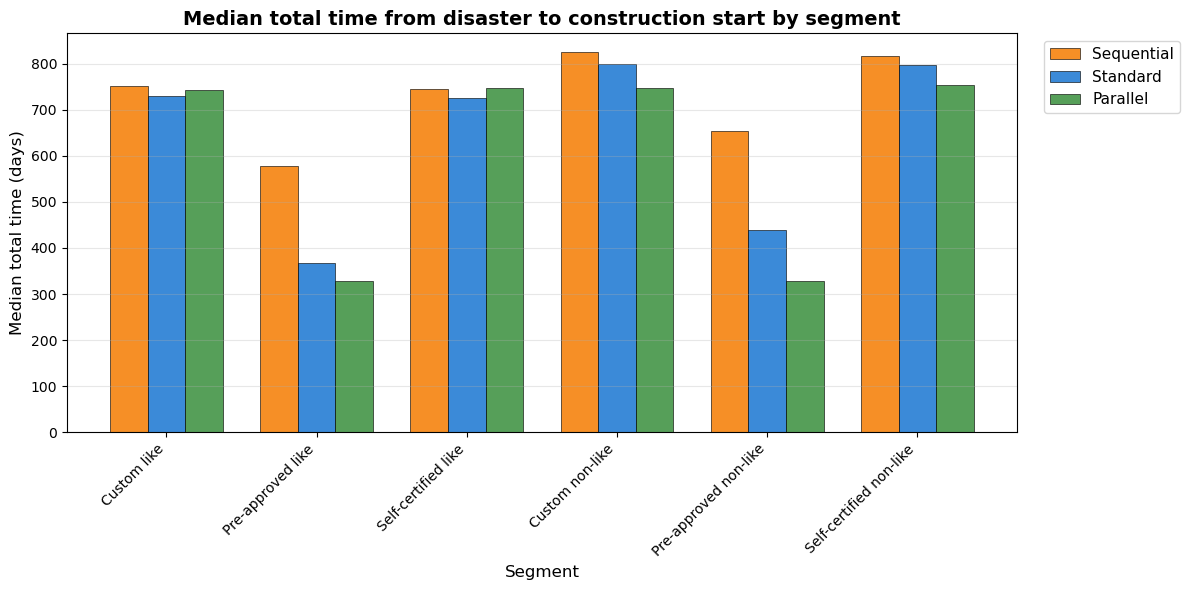

In [5]:
# Compare median total time (disaster to construction) by segment
# Use aggregated permits across many runs for each process
permits_by_process = {
    "Sequential": all_sequential_permits,
    "Standard": all_standard_permits,
    "Parallel": all_parallel_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()


SEQUENTIAL process – Segment 4 permit


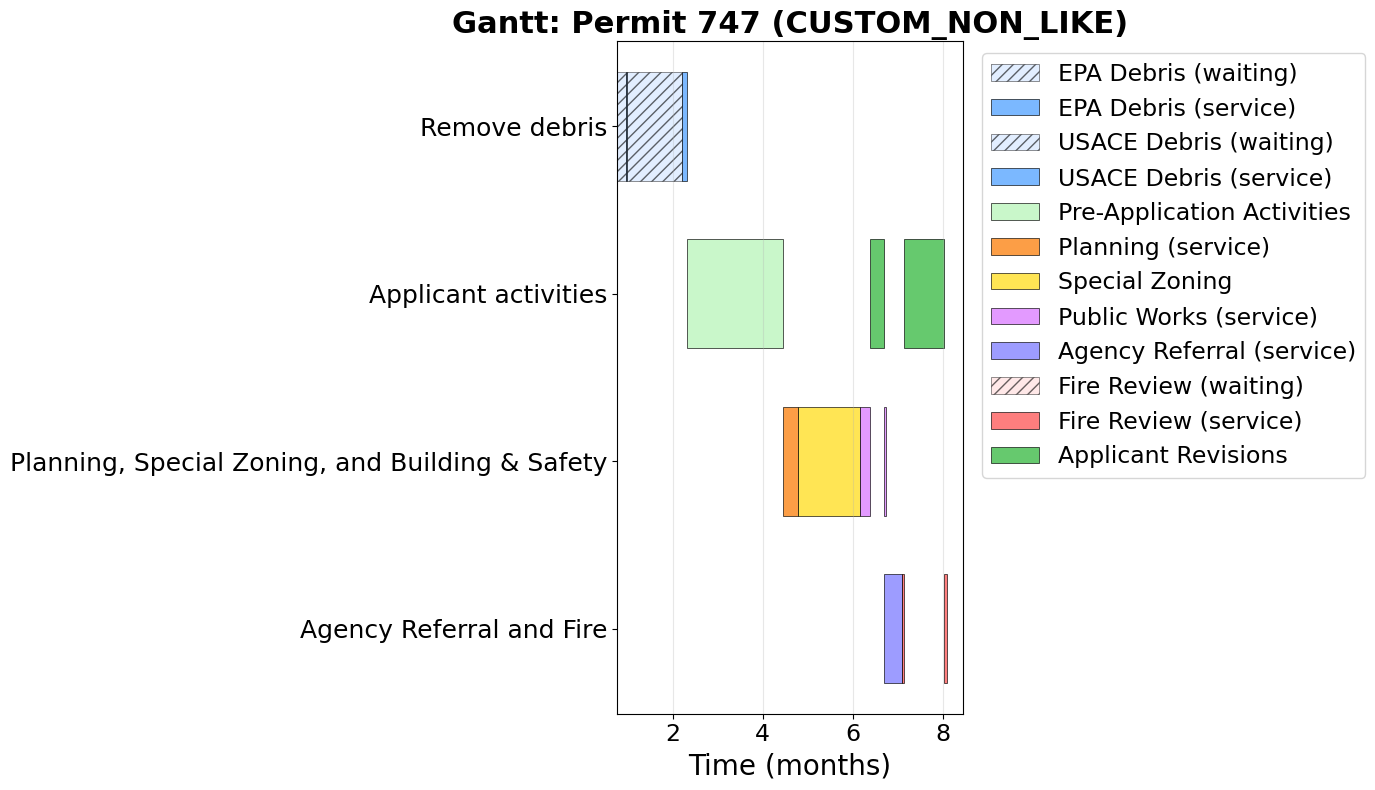


STANDARD process – Segment 4 permit


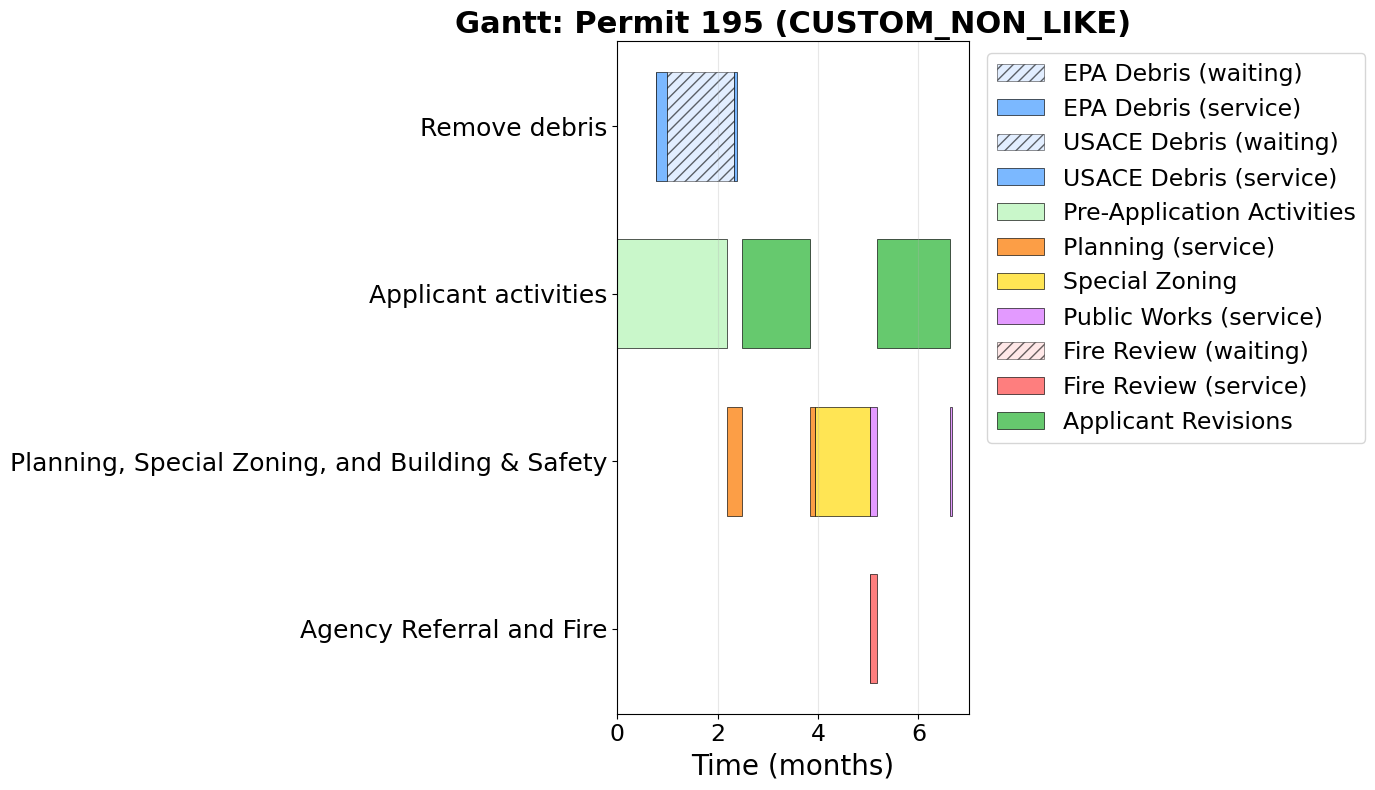


PARALLEL process – Segment 4 permit


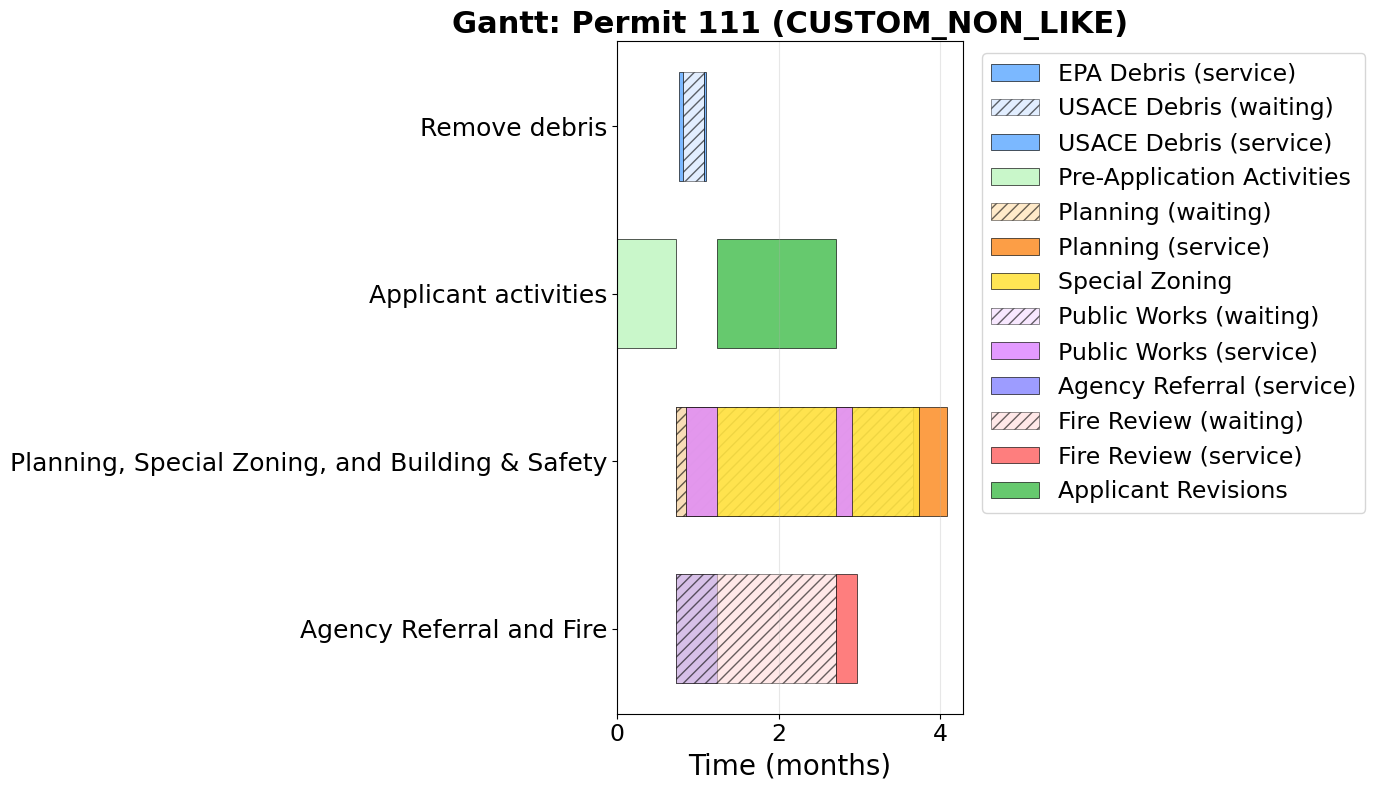

In [6]:
# Gantt charts for one random Segment 4 permit under each process
print("SEQUENTIAL process – Segment 4 permit")
fig1, ax1 = plot_gantt_one_random_permit_segment(
    sim_sequential.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig1 is not None:
    plt.show()

print("\nSTANDARD process – Segment 4 permit")
fig2, ax2 = plot_gantt_one_random_permit_segment(
    sim_standard.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig2 is not None:
    plt.show()

print("\nPARALLEL process – Segment 4 permit")
fig3, ax3 = plot_gantt_one_random_permit_segment(
    sim_parallel.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig3 is not None:
    plt.show()


Creating visualizations for SEQUENTIAL process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...
Average waiting and service time by step (days):
  EPA Debris: waiting mean=8.24, σ=5.41; service mean=1.51, σ=1.24
  USACE Debris: waiting mean=55.17, σ=29.90; service mean=1.92, σ=1.32
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=60.65, σ=39.31
  Planning: waiting mean=404.08, σ=272.94; service mean=6.84, σ=3.10
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=62.65, σ=60.92
  Public Works: waiting mean=0.01, σ=0.09; service mean=5.56, σ=4.62
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=35.96, σ=28.23
  Fire Review: waiting mean=6.24, σ=5.32; service mean=3.58, σ=3.49
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=118.91, σ=50.66


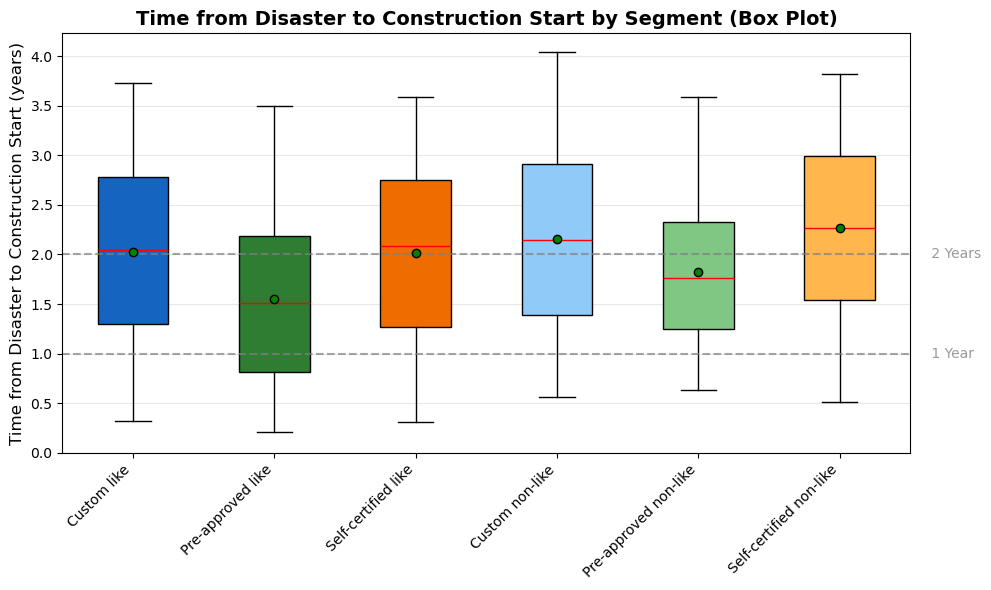

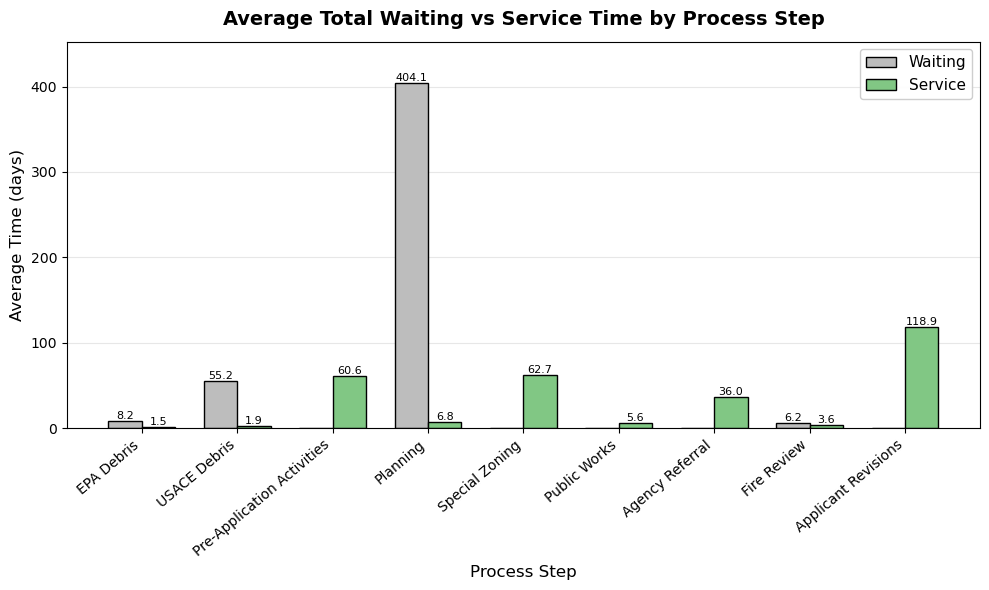

Visualizations complete!


In [7]:
# Full visualization set for each process (mirrors prior single-process notebooks)
print("Creating visualizations for SEQUENTIAL process...")
visualize_all(sim_sequential.completed_permits, save_prefix=None, show=True)



Creating visualizations for STANDARD process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...
Average waiting and service time by step (days):
  EPA Debris: waiting mean=8.20, σ=5.35; service mean=1.50, σ=1.25
  USACE Debris: waiting mean=57.98, σ=31.47; service mean=2.02, σ=1.42
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=61.85, σ=39.25
  Planning: waiting mean=458.73, σ=283.29; service mean=6.74, σ=2.95
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=61.85, σ=53.36
  Public Works: waiting mean=0.02, σ=0.15; service mean=5.59, σ=4.69
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=38.03, σ=29.20
  Fire Review: waiting mean=19.23, σ=10.82; service mean=3.74, σ=3.80
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=95.70, σ=41.34


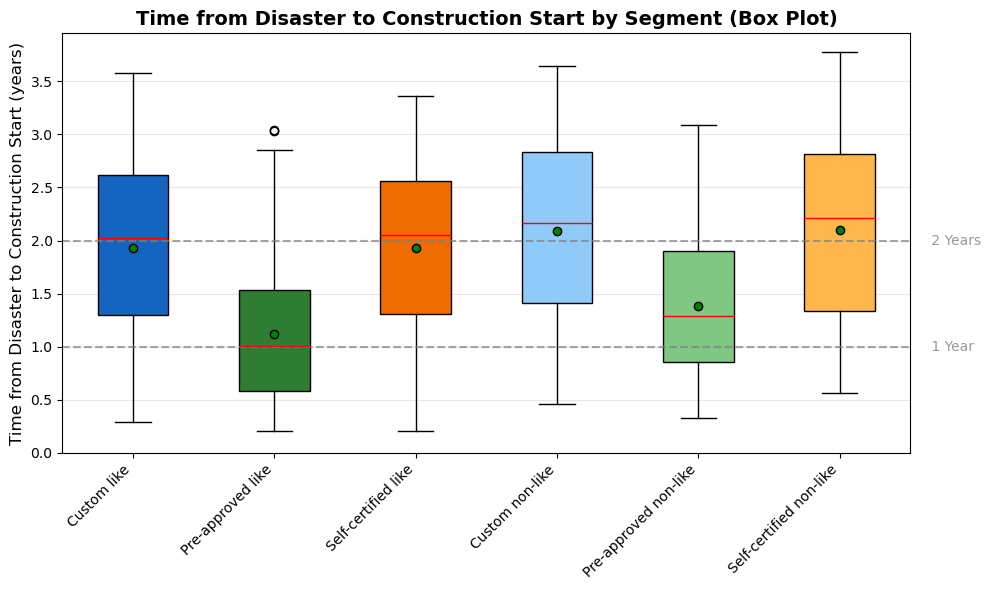

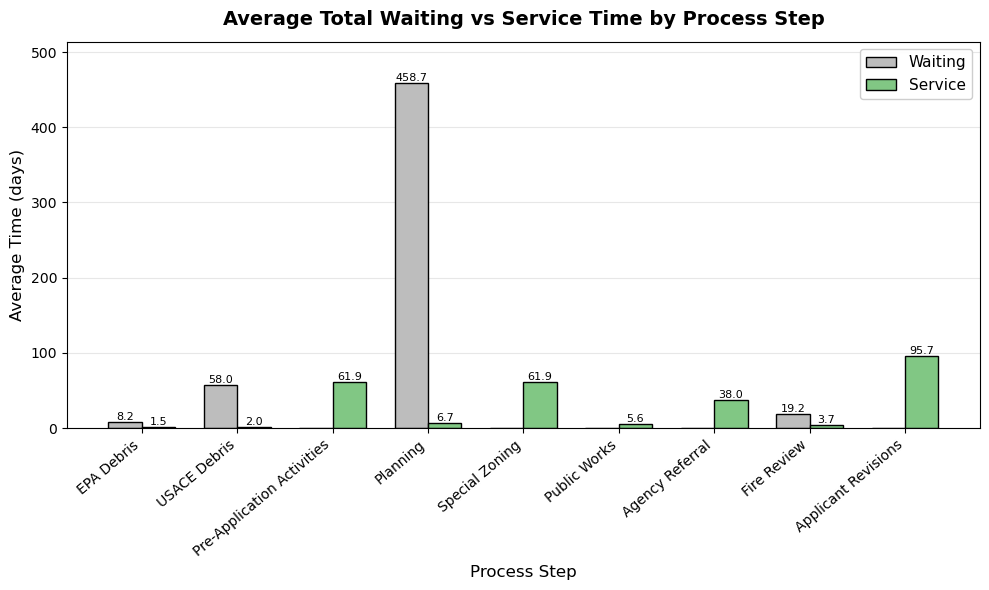

Visualizations complete!


In [8]:
print("\nCreating visualizations for STANDARD process...")
visualize_all(sim_standard.completed_permits, save_prefix=None, show=True)


Creating visualizations for PARALLEL process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...
Average waiting and service time by step (days):
  EPA Debris: waiting mean=8.13, σ=5.28; service mean=1.50, σ=1.24
  USACE Debris: waiting mean=57.39, σ=31.54; service mean=2.02, σ=1.41
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=61.85, σ=39.25
  Planning: waiting mean=453.75, σ=282.91; service mean=6.72, σ=2.98
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=56.47, σ=41.08
  Public Works: waiting mean=209.31, σ=163.62; service mean=5.43, σ=4.42
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=40.42, σ=33.83
  Fire Review: waiting mean=478.49, σ=280.38; service mean=3.80, σ=3.71
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=97.52, σ=42.25


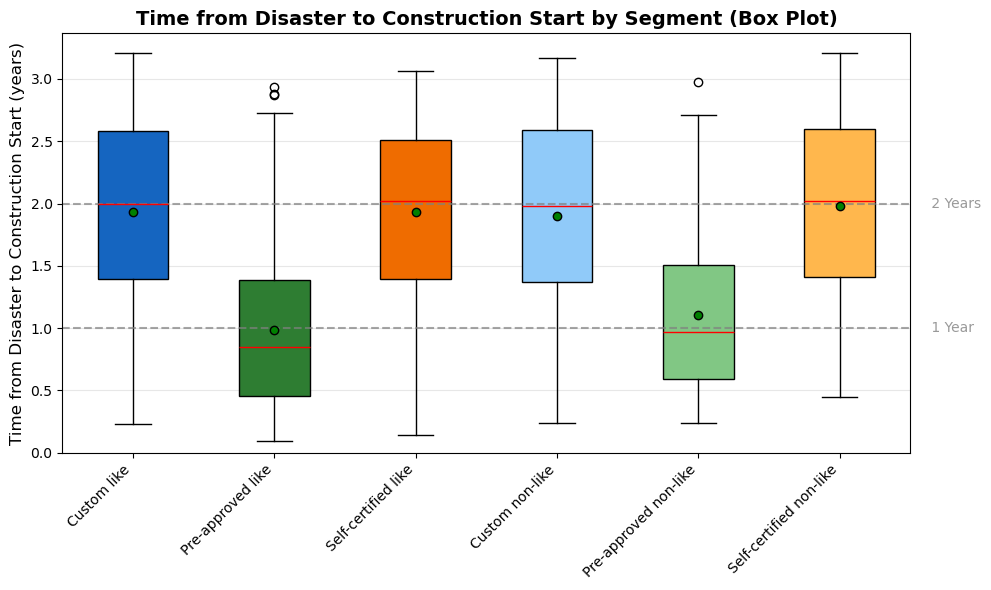

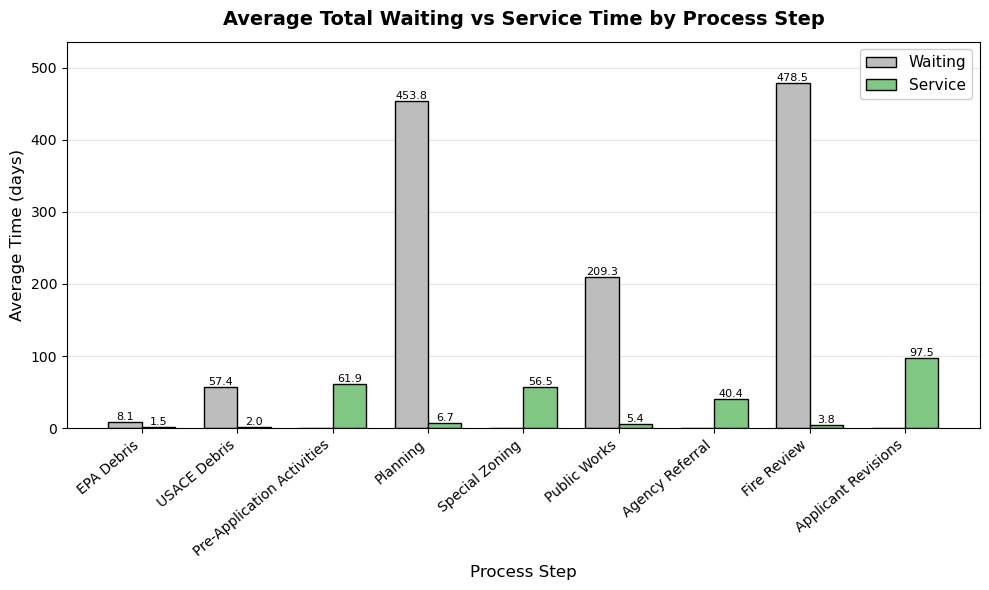

Visualizations complete!


In [9]:
print("\nCreating visualizations for PARALLEL process...")
visualize_all(sim_parallel.completed_permits, save_prefix=None, show=True)

In [10]:
# Diagnostic: like-for-like step-level timeline comparison by process
import pandas as pd
from permit_simulation import Segment

LIKE_SEGMENTS = {
    Segment.PRE_APPROVED_LIKE,
    Segment.CUSTOM_LIKE,
    Segment.SELF_CERT_LIKE,
}


def _like_step_summary(permits: list) -> dict:
    like_only = [p for p in permits if p.segment in LIKE_SEGMENTS and p.ready_for_construction is not None]
    if not like_only:
        return {"n": 0}

    def _mean(values):
        vals = [v for v in values if v is not None]
        return float(np.mean(vals)) if vals else np.nan

    return {
        "n": len(like_only),
        "total_time": _mean([p.ready_for_construction - p.created_at for p in like_only]),
        "application_to_construction": _mean([
            (p.ready_for_construction - p.planning_request)
            for p in like_only
            if p.planning_request is not None
        ]),
        "planning_wait": _mean([p.planning_total_waiting for p in like_only]),
        "planning_service": _mean([p.planning_initial_service + p.planning_recheck_service for p in like_only]),
        "public_works_wait": _mean([p.public_works_total_waiting for p in like_only]),
        "public_works_service": _mean([p.public_works_initial_service + p.public_works_recheck_service for p in like_only]),
        "fire_wait": _mean([p.fire_review_total_waiting for p in like_only]),
        "fire_service": _mean([p.fire_initial_service + p.fire_recheck_service for p in like_only]),
        "special_zoning_service": _mean([
            (p.zoning_end - p.zoning_start)
            if p.zoning_start is not None and p.zoning_end is not None
            else 0.0
            for p in like_only
        ]),
        "agency_referral_total": _mean([
            (p.agency_referral_end - p.agency_referral_request)
            if p.agency_referral_request is not None and p.agency_referral_end is not None
            else 0.0
            for p in like_only
        ]),
        "applicant_revisions": _mean([p.applicant_revisions_total_time for p in like_only]),
        "planning_rechecks": _mean([p.planning_rechecks for p in like_only]),
        "public_works_rechecks": _mean([p.public_works_rechecks for p in like_only]),
        "fire_rechecks": _mean([p.fire_rechecks for p in like_only]),
    }


process_like = {
    "Sequential": _like_step_summary(all_sequential_permits),
    "Standard": _like_step_summary(all_standard_permits),
    "Parallel": _like_step_summary(all_parallel_permits),
}

comparison_df = pd.DataFrame(process_like).T
comparison_df = comparison_df[[
    "n",
    "total_time",
    "application_to_construction",
    "planning_wait",
    "planning_service",
    "public_works_wait",
    "public_works_service",
    "fire_wait",
    "fire_service",
    "special_zoning_service",
    "agency_referral_total",
    "applicant_revisions",
    "planning_rechecks",
    "public_works_rechecks",
    "fire_rechecks",
]].round(2)

print("Like-for-like diagnostics by process (mean days unless noted):")
display(comparison_df)

if "Standard" in comparison_df.index:
    delta_vs_standard = (comparison_df - comparison_df.loc["Standard"]).round(2)
    print("\nDelta vs Standard (mean days unless noted):")
    display(delta_vs_standard)


Like-for-like diagnostics by process (mean days unless noted):


,n,total_time,application_to_construction,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,special_zoning_service,agency_referral_total,applicant_revisions,planning_rechecks,public_works_rechecks,fire_rechecks
Sequential,160204.0,701.58,549.27,404.65,6.01,0.01,5.51,11.10,3.69,0.0,0.0,118.29,1.0,1.0,0.63
Standard,160204.0,630.45,569.77,461.36,6.01,0.01,5.51,11.49,3.70,0.0,0.0,95.15,1.0,1.0,0.63
Parallel,160204.0,631.87,571.20,461.65,6.01,210.92,5.51,463.93,3.69,0.0,0.0,104.32,1.0,1.0,0.63



Delta vs Standard (mean days unless noted):


,n,total_time,application_to_construction,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,special_zoning_service,agency_referral_total,applicant_revisions,planning_rechecks,public_works_rechecks,fire_rechecks
Sequential,0.0,71.13,-20.50,-56.71,0.0,0.00,0.0,-0.39,-0.01,0.0,0.0,23.14,0.0,0.0,0.0
Standard,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0
Parallel,0.0,1.42,1.43,0.29,0.0,210.91,0.0,452.44,-0.01,0.0,0.0,9.17,0.0,0.0,0.0


### Median total time by segment — full scenario grid

Runs **sequential / standard / parallel** for every combination of **staffing** (low / medium / high), **permit volume** (2,000 vs 6,500), and **pre-application distribution** (`lognormal_10`, `lognormal_60`, `lognormal_180`). Each panel matches the previous “median total time by process” figure; figures are saved under `results/median_total_time_by_process/`.

Lower `N_RUNS_GRID` for a quick test; increase for publication-quality medians.

**Progress:** install `tqdm` (`pip install tqdm`, listed in `requirements.txt`). Toggle `SHOW_PROGRESS_OUTER` / `SHOW_PROGRESS_RUNS` for the scenario vs per-batch progress bars. In cell 4 (multi-run), use `SHOW_MULTI_RUN_PROGRESS`.


In [11]:
import csv
import json
import statistics
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
from run_simulation import run_multiple_simulations
from visualize_permits import plot_median_total_time_by_process

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None  # type: ignore

# Progress: outer bar = scenario figures; inner bar = each batch (N_RUNS × 3 processes)
SHOW_PROGRESS_OUTER = True
SHOW_PROGRESS_RUNS = True

# Matches policy / volume comparison notebooks (caseload 7 per stage)
STAFFING_SCENARIOS = {
    "low": {
        "planning_staff_count": 2,
        "public_works_staff_count": 3,
        "fire_staff_count": 1,
    },
    "medium": {
        "planning_staff_count": 8,
        "public_works_staff_count": 12,
        "fire_staff_count": 4,
    },
    "high": {
        "planning_staff_count": 20,
        "public_works_staff_count": 30,
        "fire_staff_count": 10,
    },
}

PRE_APPLICATION_DISTS = ["lognormal_10", "lognormal_60", "lognormal_180"]
PERMIT_COUNTS = [2000, 6500]

# Monte Carlo runs **per process** (Sequential, Standard, Parallel) for each scenario cell
N_RUNS_GRID = 100
BASE_SEED_GRID = 42

SHARED_KNOBS = {
    "simulation_duration": None,
    "ai_review": "none",
    "permit_mix": "balanced",
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_caseload_per_staff": 7,
    "public_works_caseload_per_staff": 7,
    "fire_caseload_per_staff": 7,
}

results_dir = Path("results") / "median_total_time_by_process"
results_dir.mkdir(parents=True, exist_ok=True)

n_scenarios = len(STAFFING_SCENARIOS) * len(PERMIT_COUNTS) * len(PRE_APPLICATION_DISTS)
total_sims = n_scenarios * N_RUNS_GRID * 3
print(
    f"Generating {n_scenarios} scenario figures; up to {total_sims} total simulation runs."
)

use_inner_progress = SHOW_PROGRESS_RUNS and tqdm is not None
if SHOW_PROGRESS_RUNS and tqdm is None:
    print("Note: install tqdm (`pip install tqdm`) for per-run progress bars.")


def permit_to_row(permit):
    if isinstance(permit, dict):
        base_row = permit
    elif hasattr(permit, "to_dict"):
        base_row = permit.to_dict()  # type: ignore[attr-defined]
    elif hasattr(permit, "__dict__"):
        base_row = vars(permit)
    else:
        base_row = {"permit_repr": repr(permit)}

    clean_row = {}
    for k, v in base_row.items():
        if isinstance(v, (str, int, float, bool)) or v is None:
            clean_row[k] = v
        else:
            clean_row[k] = json.dumps(v, sort_keys=True, default=str)
    return clean_row


def get_application_to_ready_days(permit):
    ready_time = getattr(permit, "ready_for_construction", None)
    created_time = getattr(permit, "created_at", None)
    if ready_time is None or created_time is None:
        return None
    return float(ready_time - created_time)


all_output_rows = []
scenario_summary_rows = []

scenario_grid = list(
    product(STAFFING_SCENARIOS.items(), PERMIT_COUNTS, PRE_APPLICATION_DISTS)
)
scenario_iter = (
    tqdm(scenario_grid, desc="Scenario figures", unit="fig")
    if SHOW_PROGRESS_OUTER and tqdm is not None
    else scenario_grid
)

for (staffing_name, staff_counts), num_perm, pre_dist in scenario_iter:
    scenario_params_list = []
    base = dict(SHARED_KNOBS)
    base.update(staff_counts)
    base["pre_application_distribution"] = pre_dist

    for proc_name, seq in [
        ("Sequential", "sequential"),
        ("Standard", "standard"),
        ("Parallel", "parallel"),
    ]:
        scenario_params_list.append(
            {
                "name": proc_name,
                "sequential": seq,
                "num_permits": num_perm,
                **base,
            }
        )

    multi_results = run_multiple_simulations(
        n_runs=N_RUNS_GRID,
        num_permits=num_perm,
        simulation_duration=None,
        base_seed=BASE_SEED_GRID,
        scenario_params_list=scenario_params_list,
        collect_permits=True,
        show_progress=use_inner_progress,
        progress_desc=f"{staffing_name} | n={num_perm} | {pre_dist}",
        progress_leave=False,
    )

    all_seq, all_std, all_par = [], [], []
    for res in multi_results:
        plist = res.get("permits", [])
        scenario = res["scenario"]

        total_times = []
        for permit in plist:
            total_time = get_application_to_ready_days(permit)
            if total_time is not None:
                total_times.append(total_time)

            permit_row = permit_to_row(permit)
            all_output_rows.append(
                {
                    "staffing_scenario": staffing_name,
                    "permit_count": num_perm,
                    "pre_application_distribution": pre_dist,
                    "process": scenario,
                    "application_to_ready_days": total_time,
                    **permit_row,
                }
            )

        scenario_summary_rows.append(
            {
                "staffing_scenario": staffing_name,
                "permit_count": num_perm,
                "pre_application_distribution": pre_dist,
                "process": scenario,
                "n_completed_permits": len(total_times),
                "application_to_ready_median_days": (
                    statistics.median(total_times) if total_times else None
                ),
                "application_to_ready_mean_days": (
                    statistics.mean(total_times) if total_times else None
                ),
                "application_to_ready_std_days": (
                    statistics.stdev(total_times) if len(total_times) > 1 else 0.0
                ),
            }
        )

        if scenario == "Sequential":
            all_seq.extend(plist)
        elif scenario == "Standard":
            all_std.extend(plist)
        elif scenario == "Parallel":
            all_par.extend(plist)

    permits_by_process = {
        "Sequential": all_seq,
        "Standard": all_std,
        "Parallel": all_par,
    }

    safe_pre = pre_dist.replace("lognormal_", "log")
    outfile = (
        results_dir
        / f"median_total_time_staff-{staffing_name}_permits-{num_perm}_pre-{safe_pre}.png"
    )

    title = f"Staffing={staffing_name} · Permits={num_perm:,} · Pre-app={pre_dist}"

    fig, ax = plot_median_total_time_by_process(
        permits_by_process,
        figsize=(12, 6),
        title=title,
    )
    if fig is not None:
        fig.savefig(outfile, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {outfile}")
    else:
        print(f"Skipped (no data): {title}")

csv_outfile = results_dir / "median_total_time_by_process_outputs.csv"
if all_output_rows:
    fieldnames = sorted({k for row in all_output_rows for k in row})
    with csv_outfile.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_output_rows)
    print(f"Saved {csv_outfile} ({len(all_output_rows):,} rows)")
else:
    print("No output rows collected; CSV not written.")

summary_outfile = results_dir / "median_total_time_by_process_scenario_summary.csv"
if scenario_summary_rows:
    summary_fieldnames = [
        "staffing_scenario",
        "permit_count",
        "pre_application_distribution",
        "process",
        "n_completed_permits",
        "application_to_ready_median_days",
        "application_to_ready_mean_days",
        "application_to_ready_std_days",
    ]
    with summary_outfile.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
        writer.writeheader()
        writer.writerows(scenario_summary_rows)
    print(f"Saved {summary_outfile} ({len(scenario_summary_rows):,} rows)")
else:
    print("No scenario summary rows collected; summary CSV not written.")

print("Done.")




Generating 18 scenario figures; up to 5400 total simulation runs.


Scenario figures:   0%|          | 0/18 [00:00<?, ?fig/s]

low | n=2000 | lognormal_10:   0%|          | 0/300 [00:00<?, ?run/s]

Saved results/median_total_time_by_process/median_total_time_staff-low_permits-2000_pre-log10.png


low | n=2000 | lognormal_60:   0%|          | 0/300 [00:00<?, ?run/s]

...

Saved results/median_total_time_by_process/median_total_time_staff-high_permits-6500_pre-log10.png


high | n=6500 | lognormal_60:   0%|          | 0/300 [00:00<?, ?run/s]

Saved results/median_total_time_by_process/median_total_time_staff-high_permits-6500_pre-log60.png


high | n=6500 | lognormal_180:   0%|          | 0/300 [00:00<?, ?run/s]

Saved results/median_total_time_by_process/median_total_time_staff-high_permits-6500_pre-log180.png
Saved results/median_total_time_by_process/median_total_time_by_process_outputs.csv (22,950,000 rows)
Saved results/median_total_time_by_process/median_total_time_by_process_scenario_summary.csv (5,400 rows)
Done.
